In [2]:
import pandas as pd

df = pd.read_csv("final_dataset_with_all_features_v3.1.csv")

df.head()
df.tail()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 64 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   url                           651191 non-null  object 
 1   type                          651191 non-null  object 
 2   label                         651191 non-null  int64  
 3   url_len                       651191 non-null  int64  
 4   @                             651191 non-null  int64  
 5   ?                             651191 non-null  int64  
 6   -                             651191 non-null  int64  
 7   =                             651191 non-null  int64  
 8   .                             651191 non-null  int64  
 9   #                             651191 non-null  int64  
 10  %                             651191 non-null  int64  
 11  +                             651191 non-null  int64  
 12  $                             651191 non-nul

In [4]:
df['label'].value_counts()
df['label'].value_counts(normalize=True)

label
0    0.657336
1    0.148238
2    0.144485
3    0.049940
Name: proportion, dtype: float64

In [7]:
df.duplicated().sum()
df = df.drop_duplicates()
df.duplicated().sum()
df.shape

url                      0
type                     0
label                    0
url_len                  0
@                        0
                        ..
phish_adv_many_params    0
path_has_hacked_terms    0
suspicious_extension     0
path_underscore_count    0
is_gov_edu               0
Length: 64, dtype: int64

In [6]:
df.isnull().sum()

url                      0
type                     0
label                    0
url_len                  0
@                        0
                        ..
phish_adv_many_params    0
path_has_hacked_terms    0
suspicious_extension     0
path_underscore_count    0
is_gov_edu               0
Length: 64, dtype: int64

In [6]:
# Remove constant columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
df.drop(columns=constant_cols, inplace=True)

df.shape


(650682, 64)

In [7]:
df.shape
df.head()

,url,type,label,url_len,@,?,-,=,.,#,...,phish_adv_long_domain,phish_adv_many_subdomains,phish_adv_encoded_chars,phish_adv_path_keywords,phish_adv_has_redirect,phish_adv_many_params,path_has_hacked_terms,suspicious_extension,path_underscore_count,is_gov_edu
0,br-icloud.com.br,phishing,2,16,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,1,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,0,0
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1,84,0,1,1,4,2,0,...,0,0,0,0,0,3,0,1,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,1,3,2,0,...,0,0,0,0,0,2,0,1,0,0


In [9]:
target_candidates = [c for c in df.columns if c.lower() in ["label", "class", "target"]]
target_col = target_candidates[0] if target_candidates else df.columns[-1]

X = df.drop(columns=[target_col]).select_dtypes(include=["int64", "float64"])
y = df[target_col]

df_small = pd.concat([X, y], axis=1).sample(frac=0.4, random_state=42)
X = df_small.drop(columns=[target_col])
y = df_small[target_col]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

results = {}

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("Random Forest Results")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


cm_rf = confusion_matrix(y_test, y_pred_rf)
fn_rf = {}

for i in range(cm_rf.shape[0]):
    fn_rf[f"Class_{i}"] = cm_rf[i].sum() - cm_rf[i][i]

print("Feature-RF False Negatives per class:", fn_rf)
print("Total RF False Negatives:", sum(fn_rf.values()))

Random Forest Results
[[33226    34   962     3]
 [   25  7597    87    31]
 [ 2542   269  4657    23]
 [   27    67   110  2395]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     34225
           1       0.95      0.98      0.97      7740
           2       0.80      0.62      0.70      7491
           3       0.98      0.92      0.95      2599

    accuracy                           0.92     52055
   macro avg       0.91      0.87      0.89     52055
weighted avg       0.92      0.92      0.92     52055

Feature-RF False Negatives per class: {'Class_0': np.int64(999), 'Class_1': np.int64(143), 'Class_2': np.int64(2834), 'Class_3': np.int64(204)}
Total RF False Negatives: 4180


In [11]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

svm = LinearSVC(max_iter=5000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Results")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


cm_svm = confusion_matrix(y_test, y_pred_svm)
fn_svm = {}

for i in range(cm_svm.shape[0]):
    fn_svm[f"Class_{i}"] = cm_svm[i].sum() - cm_svm[i][i]

print("Feature-svm False Negatives per class:", fn_svm)
print("Total svm False Negatives:", sum(fn_svm.values()))

SVM Results
[[33797   296    39    93]
 [  249  7448    19    24]
 [ 5710   650   929   202]
 [  179   413   122  1885]]
              precision    recall  f1-score   support

           0       0.85      0.99      0.91     34225
           1       0.85      0.96      0.90      7740
           2       0.84      0.12      0.22      7491
           3       0.86      0.73      0.78      2599

    accuracy                           0.85     52055
   macro avg       0.85      0.70      0.70     52055
weighted avg       0.85      0.85      0.80     52055

Feature-svm False Negatives per class: {'Class_0': np.int64(428), 'Class_1': np.int64(292), 'Class_2': np.int64(6562), 'Class_3': np.int64(714)}
Total svm False Negatives: 7996


In [13]:
import pandas as pd
import re

df = pd.read_csv("final_dataset_with_all_features_v3.1.csv")

nlp_df = df[['url', 'label']].copy()

def clean_url(url):
    url = str(url).lower()
    url = re.sub(r'https?://', '', url)
    url = re.sub(r'www\.', '', url)
    return url

nlp_df['clean_url'] = nlp_df['url'].apply(clean_url)
nlp_df.head()


,url,label,clean_url
0,br-icloud.com.br,2,br-icloud.com.br
1,mp3raid.com/music/krizz_kaliko.html,0,mp3raid.com/music/krizz_kaliko.html
2,bopsecrets.org/rexroth/cr/1.htm,0,bopsecrets.org/rexroth/cr/1.htm
3,http://garage-pirenne.be/index.php?option=com_...,1,garage-pirenne.be/index.php?option=com_content...
4,http://adventure-nicaragua.net/index.php?optio...,1,adventure-nicaragua.net/index.php?option=com_m...


In [15]:
nlp_df.to_csv("phishing_urls_nlp_dataset.csv", index=False)


In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5)
)

X_tfidf = tfidf.fit_transform(nlp_df['clean_url'])
y = nlp_df['label']

X_tfidf.shape


(650682, 4628651)

In [22]:
import pandas as pd

nlp_df = pd.read_csv("phishing_urls_nlp_dataset.csv")
print(nlp_df.shape)
print(nlp_df['label'].value_counts())

(651191, 3)
label
0    428103
1     96457
2     94111
3     32520
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import train_test_split

X_text = nlp_df['clean_url']
y = nlp_df['label']

X_train_nlp, X_test_nlp, y_train_nlp, y_test_nlp = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5)
)

X_train_tfidf = tfidf.fit_transform(X_train_nlp)
X_test_tfidf = tfidf.transform(X_test_nlp)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)


TF-IDF Train Shape: (520952, 4128664)
TF-IDF Test Shape: (130239, 4128664)


In [25]:
import scipy.sparse as sp

sp.save_npz("X_train_tfidf.npz", X_train_tfidf)
sp.save_npz("X_test_tfidf_.npz", X_test_tfidf)

y_train_nlp.to_csv("y_train_nlp.csv", index=False)
y_test_nlp.to_csv("y_test_nlp.csv", index=False)


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

tfidf_rf = RandomForestClassifier(
    n_estimators=50,      
    max_depth=20,         
    min_samples_split=10,
    n_jobs=-1,
    random_state=42
)

tfidf_rf.fit(X_train_tfidf, y_train_nlp)
y_pred_tfidf_rf = tfidf_rf.predict(X_test_tfidf)

print(confusion_matrix(y_test_nlp, y_pred_tfidf_rf))
print(classification_report(y_test_nlp, y_pred_tfidf_rf))

cm_tfidf_rf = confusion_matrix(y_test_nlp, y_pred_tfidf_rf)
fn_tfidf_rf={}

for i in range(cm_tfidf_rf.shape[0]):
    fn_tfidf_rf[f"Class_{i}"] = cm_tfidf_rf[i].sum() - cm_tfidf_rf[i][i]

print("TF-IDF + RF False Negatives per class:", fn_tfidf_rf)
print("Total RF False Negatives:", sum(fn_tfidf_rf.values()))

[[85537    84     0     0]
 [10269  9023     0     0]
 [18057     0   765     0]
 [ 4951    75     1  1477]]
              precision    recall  f1-score   support

           0       0.72      1.00      0.84     85621
           1       0.98      0.47      0.63     19292
           2       1.00      0.04      0.08     18822
           3       1.00      0.23      0.37      6504

    accuracy                           0.74    130239
   macro avg       0.93      0.43      0.48    130239
weighted avg       0.81      0.74      0.67    130239

TF-IDF + RF False Negatives per class: {'Class_0': np.int64(84), 'Class_1': np.int64(10269), 'Class_2': np.int64(18057), 'Class_3': np.int64(5027)}
Total RF False Negatives: 33437


In [29]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

tfidf_svm = LinearSVC(max_iter=5000)
tfidf_svm.fit(X_train_tfidf, y_train_nlp)

y_pred_tfidf_svm = tfidf_svm.predict(X_test_tfidf)

print("TF-IDF + SVM Results")
print(confusion_matrix(y_test_nlp, y_pred_tfidf_svm))
print(classification_report(y_test_nlp, y_pred_tfidf_svm))

cm_tfidf_svm = confusion_matrix(y_test_nlp, y_pred_tfidf_svm)
fn_tfidf_svm={}

for i in range(cm_tfidf_svm.shape[0]):
    fn_tfidf_svm[f"Class_{i}"] = cm_tfidf_svm[i].sum() - cm_tfidf_svm[i][i]

print("TF-IDF + SVM False Negatives per class:", fn_tfidf_svm)
print("Total SVM False Negatives:", sum(fn_tfidf_svm.values()))

TF-IDF + SVM Results
[[83809    96  1703    13]
 [   38 19240    14     0]
 [ 3459    51 15297    15]
 [   46     3   174  6281]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     85621
           1       0.99      1.00      0.99     19292
           2       0.89      0.81      0.85     18822
           3       1.00      0.97      0.98      6504

    accuracy                           0.96    130239
   macro avg       0.96      0.94      0.95    130239
weighted avg       0.96      0.96      0.96    130239

TF-IDF + SVM False Negatives per class: {'Class_0': np.int64(1812), 'Class_1': np.int64(52), 'Class_2': np.int64(3525), 'Class_3': np.int64(223)}
Total SVM False Negatives: 5612


In [30]:
results = {
    "Model": [
        "Feature-RF",
        "Feature-SVM",
        "NLP TF-IDF + RF",
        "NLP TF-IDF + SVM"
    ],
    "Accuracy": [0.92, 0.85, 0.74, 0.96],
    "Precision": [0.93, 0.85, 0.72, 0.96],
    "Recall": [0.97, 0.99, 1.00, 0.98],
    "F1-Score": [0.95, 0.91, 0.84, 0.97]
}

df_results = pd.DataFrame(results)
df_results


,Model,Accuracy,Precision,Recall,F1-Score
0,Feature-RF,0.92,0.93,0.97,0.95
1,Feature-SVM,0.85,0.85,0.99,0.91
2,NLP TF-IDF + RF,0.74,0.72,1.00,0.84
3,NLP TF-IDF + SVM,0.96,0.96,0.98,0.97


In [31]:
# [[TN, FP],
#  [FN, TP]]

confusion_data = {
    "Model": ["Feature-RF", "Feature-SVM", "NLP TF-IDF + RF", "NLP TF-IDF + SVM"],
    "Total False Negatives": [4180, 7996, 33437, 5612]   
}

df_fn = pd.DataFrame(confusion_data)
df_fn


,Model,Total False Negatives
0,Feature-RF,4180
1,Feature-SVM,7996
2,NLP TF-IDF + RF,33437
3,NLP TF-IDF + SVM,5612


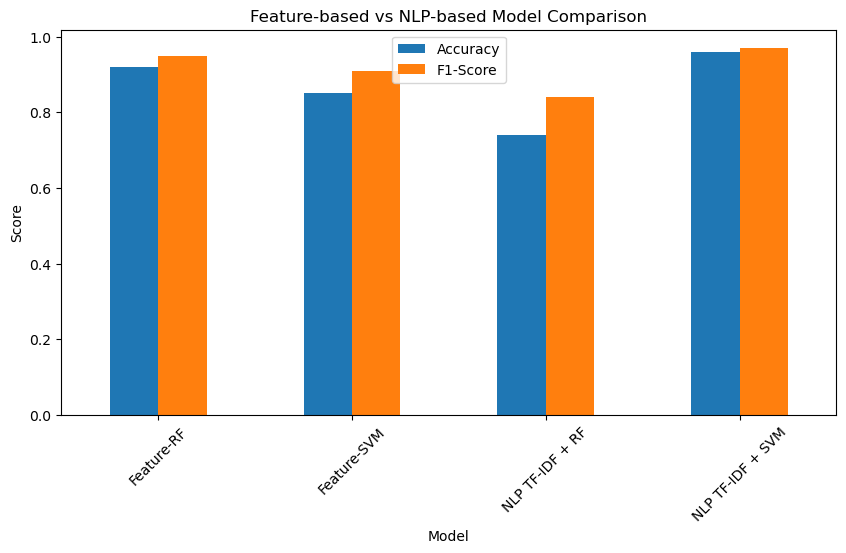

In [32]:
import matplotlib.pyplot as plt

df_results.plot(
    x="Model",
    y=["Accuracy", "F1-Score"],
    kind="bar",
    figsize=(10,5)
)
plt.title("Feature-based vs NLP-based Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


In [33]:
import pandas as pd
from sklearn.metrics import confusion_matrix

nlp_df = pd.read_csv("phishing_urls_nlp_dataset.csv")

cm = confusion_matrix(y_test_nlp, y_pred_tfidf_svm)
cm


array([[83809,    96,  1703,    13],
       [   38, 19240,    14,     0],
       [ 3459,    51, 15297,    15],
       [   46,     3,   174,  6281]])

In [34]:

y_test_series = y_test_nlp.reset_index(drop=True)
y_pred_series = pd.Series(y_pred_tfidf_svm)

false_negatives = nlp_df.iloc[y_test_series.index][
    (y_test_series == 1) & (y_pred_series == 0)
]

false_negatives[['url', 'clean_url']].head(10)


,url,clean_url
10216,torrentreactor.net/torrents/4200776/MOZART-THE...,torrentreactor.net/torrents/4200776/mozart-the...
21894,http://mp3-pesnja.com/song/%D0%BB%D1%8E%D0%B1%...,mp3-pesnja.com/song/%d0%bb%d1%8e%d0%b1%d0%be%d...
22857,unblocking-fb-support.xyz,unblocking-fb-support.xyz
23778,vh1.com/news/rock_clock/11_20/index.jhtml,vh1.com/news/rock_clock/11_20/index.jhtml
28403,familytreeassistant.com/surnames/surnames.php?...,familytreeassistant.com/surnames/surnames.php?...
31121,assnat.qc.ca/en/deputes/ouimet-francois-857/in...,assnat.qc.ca/en/deputes/ouimet-francois-857/in...
40661,clarabia.com.br,clarabia.com.br
41444,johnnyminishop.blogspot.com/2010/03/preorder-a...,johnnyminishop.blogspot.com/2010/03/preorder-a...
41891,https://twitter.com/share?url=http%3A%2F%2Fhub...,twitter.com/share?url=http%3a%2f%2fhubpages.co...
42995,homepages.rootsweb.ancestry.com/~maryc/brant77...,homepages.rootsweb.ancestry.com/~maryc/brant77...


In [35]:
false_positives = nlp_df.iloc[y_test_series.index][
    (y_test_series == 0) & (y_pred_series == 1)
]

false_positives[['url', 'clean_url']].head(10)


,url,clean_url
730,smarticullties.com,smarticullties.com
1962,gramadocargoexpress.com.br,gramadocargoexpress.com.br
4289,http://notiamazonia.com/index.php?option=com_c...,notiamazonia.com/index.php?option=com_content&...
4776,manta.com/c/mm3d2gb/larry-bartlett-inc,manta.com/c/mm3d2gb/larry-bartlett-inc
5903,paperbacknovel.com/novels/cone.htm,paperbacknovel.com/novels/cone.htm
6298,facebook.com/pages/Bill-Torrey/103827362989012,facebook.com/pages/bill-torrey/103827362989012
9856,candystand.com/play/topsy-turvy,candystand.com/play/topsy-turvy
14346,food.computer4u.in.th/,food.computer4u.in.th/
16150,bleacherreport.com/articles/56667-bts-200809-n...,bleacherreport.com/articles/56667-bts-200809-n...
17781,ultimate-guitar.com/,ultimate-guitar.com/


In [36]:
from sklearn.metrics import confusion_matrix
import pandas as pd
df= pd.read_csv("final_dataset_with_all_features_v3.1.csv")

cm_feat = confusion_matrix(y_test, y_pred_rf)
cm_feat


array([[33226,    34,   962,     3],
       [   25,  7597,    87,    31],
       [ 2542,   269,  4657,    23],
       [   27,    67,   110,  2395]])

In [37]:
fn_feat = df.iloc[y_test.index][
    (y_test == 1) & (y_pred_rf == 0)
]

fn_feat.head(10)


,url,type,label,url_len,@,?,-,=,.,#,...,phish_adv_long_domain,phish_adv_many_subdomains,phish_adv_encoded_chars,phish_adv_path_keywords,phish_adv_has_redirect,phish_adv_many_params,path_has_hacked_terms,suspicious_extension,path_underscore_count,is_gov_edu
293846,http://cmmtoronto.com/pt/medite/item/44-vessel...,defacement,1,92,0,0,10,0,1,0,...,0,0,0,0,0,0,0,0,0,0
512113,http://slaviacapital.com/tlacove-spravy-eng/sl...,defacement,1,110,0,0,11,0,1,0,...,0,0,0,0,0,0,0,0,0,0
44001,http://slavia.sk/tlacove-spravy-eng/loan-manag...,defacement,1,142,0,0,17,0,1,0,...,0,0,0,0,0,0,0,0,0,0
175637,http://congaltonheating.com/congalton-heating-...,defacement,1,149,0,0,15,0,1,0,...,0,0,0,0,0,0,0,0,0,0
206886,http://slavia.sk/tlacove-spravy-eng/slavia-cap...,defacement,1,89,0,0,9,0,1,0,...,0,0,0,0,0,0,0,0,0,0
35968,http://construtoraelevacao.com.br/videos/const...,defacement,1,114,0,0,9,0,2,0,...,0,0,0,0,0,0,0,0,0,0
27859,http://construtoraelevacao.com.br/videos/geral...,defacement,1,105,0,0,8,0,2,0,...,0,0,0,0,0,0,0,0,0,0
217850,http://gypsyspirit.eu/en/2009/3-archiv-novinie...,defacement,1,110,0,0,12,0,1,0,...,0,0,0,0,0,0,0,0,0,0
206222,http://orchiddentalcentre.com/dental-treatment...,defacement,1,84,0,0,3,0,2,0,...,0,0,0,0,0,0,0,1,0,0
435852,http://pressboxsportslounge.com/component/cont...,defacement,1,90,0,0,4,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
# Length of misclassified URLs
false_negatives['url_length'] = false_negatives['clean_url'].apply(len)
false_negatives['url_length'].describe()


count     38.000000
mean      58.157895
std       41.028353
min       14.000000
25%       31.250000
50%       49.000000
75%       69.500000
max      212.000000
Name: url_length, dtype: float64

In [40]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd

df = pd.read_csv("phishing_urls_nlp_dataset.csv")

X_text = df['clean_url']
y = df['label']


In [42]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_chars = 200   

tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(X_text)

sequences = tokenizer.texts_to_sequences(X_text)
X_seq = pad_sequences(sequences, maxlen=max_chars, padding='post')


In [43]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_seq, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout,Input

vocab_size = len(tokenizer.word_index) + 1

cnn_model = Sequential([
    Input(shape=(max_chars,)),
    Embedding(input_dim=vocab_size, output_dim=50),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

cnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 50)        │        13,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 196, 64)        │        16,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 94, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6016)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       770,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841,694 (3.21 MB)

 Trainable params: 841,694 (3.21 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
#training
cnn_history = cnn_model.fit(
    X_train_dl, y_train_dl,
    epochs=5,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 113s 31ms/step - accuracy: 0.8777 - loss: 0.3261 - val_accuracy: 0.9162 - val_loss: 0.2113
Epoch 2/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 111s 30ms/step - accuracy: 0.9219 - loss: 0.2038 - val_accuracy: 0.9280 - val_loss: 0.1828
Epoch 3/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 110s 30ms/step - accuracy: 0.9319 - loss: 0.1752 - val_accuracy: 0.9324 - val_loss: 0.1753
Epoch 4/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 113s 31ms/step - accuracy: 0.9376 - loss: 0.1592 - val_accuracy: 0.9366 - val_loss: 0.1667
Epoch 5/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 112s 31ms/step - accuracy: 0.9417 - loss: 0.1484 - val_accuracy: 0.9363 - val_loss: 0.1724


In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

cnn_predictions = cnn_model.predict(X_test_dl)
y_pred_cnn = np.argmax(cnn_predictions, axis=1)

print(confusion_matrix(y_test_dl, y_pred_cnn))
print(classification_report(y_test_dl, y_pred_cnn))

cm_cnn = confusion_matrix(y_test_dl, y_pred_cnn)
fn_cnn = {}

for i in range(cm_cnn.shape[0]):
    fn_cnn[f"Class_{i}"] = cm_cnn[i].sum() - cm_cnn[i][i]

print("CNN False Negatives per class:", fn_cnn)
print("Total CNN False Negatives:", sum(fn_cnn.values()))


4070/4070 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
[[82979   190  2410    42]
 [  323 18807   157     5]
 [ 4790    83 13908    41]
 [   78     2   199  6225]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     85621
           1       0.99      0.97      0.98     19292
           2       0.83      0.74      0.78     18822
           3       0.99      0.96      0.97      6504

    accuracy                           0.94    130239
   macro avg       0.94      0.91      0.92    130239
weighted avg       0.93      0.94      0.93    130239

CNN False Negatives per class: {'Class_0': np.int64(2642), 'Class_1': np.int64(485), 'Class_2': np.int64(4914), 'Class_3': np.int64(279)}
Total CNN False Negatives: 8320


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input

vocab_size = len(tokenizer.word_index) + 1

lstm_model = Sequential([
    Input(shape=(max_chars,)),
    Embedding(vocab_size, 64),
    LSTM(128, return_sequences=False),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │        17,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,060 (488.52 KB)

 Trainable params: 125,060 (488.52 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl),
    y=y_train_dl
)

class_weights = dict(enumerate(class_weights))
class_weights

lstm_history = lstm_model.fit(
    X_train_dl,
    y_train_dl,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weights
)

Epoch 1/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 613s 167ms/step - accuracy: 0.2589 - loss: 1.2997 - val_accuracy: 0.4770 - val_loss: 1.0201
Epoch 2/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 591s 161ms/step - accuracy: 0.6972 - loss: 0.5560 - val_accuracy: 0.8094 - val_loss: 0.4328
Epoch 3/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 594s 162ms/step - accuracy: 0.8138 - loss: 0.3439 - val_accuracy: 0.8200 - val_loss: 0.3859
Epoch 4/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 591s 161ms/step - accuracy: 0.8417 - loss: 0.2760 - val_accuracy: 0.8692 - val_loss: 0.3019
Epoch 5/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 591s 161ms/step - accuracy: 0.8621 - loss: 0.2369 - val_accuracy: 0.8500 - val_loss: 0.3351


In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
pred_lstm = lstm_model.predict(X_test_dl)
y_pred_lstm = np.argmax(pred_lstm, axis=1)

print(confusion_matrix(y_test_dl, y_pred_lstm))
print(classification_report(y_test_dl, y_pred_lstm))

cm_lstm = confusion_matrix(y_test_dl, y_pred_lstm)
fn_lstm = {}

for i in range(cm_lstm.shape[0]):
    fn_lstm[f"Class_{i}"] = cm_lstm[i].sum() - cm_lstm[i][i]

print("LSTM False Negatives per class:", fn_lstm)
print("Total LSTM False Negatives:", sum(fn_lstm.values()))


4070/4070 ━━━━━━━━━━━━━━━━━━━━ 113s 28ms/step
[[68590  2048 14492   491]
 [   79 19097   111     5]
 [ 1433   517 16781    91]
 [   38    25   224  6217]]
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     85621
           1       0.88      0.99      0.93     19292
           2       0.53      0.89      0.67     18822
           3       0.91      0.96      0.93      6504

    accuracy                           0.85    130239
   macro avg       0.83      0.91      0.85    130239
weighted avg       0.90      0.85      0.86    130239

LSTM False Negatives per class: {'Class_0': np.int64(17031), 'Class_1': np.int64(195), 'Class_2': np.int64(2041), 'Class_3': np.int64(287)}
Total LSTM False Negatives: 19554


In [56]:
from tensorflow.keras.layers import Bidirectional,Embedding, Dense, Dropout, Input
from tensorflow.keras.models import Sequential 

bilstm_model = Sequential([
    Input(shape=(max_chars,)),
    Embedding(vocab_size, 64),
    Bidirectional(LSTM(128)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 64)        │        17,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,068 (906.52 KB)

 Trainable params: 232,068 (906.52 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl),
    y=y_train_dl
)

class_weights = dict(enumerate(class_weights))
class_weights

bilstm_model.fit(
    X_train_dl,
    y_train_dl,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weights
)


Epoch 1/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 898s 244ms/step - accuracy: 0.6987 - loss: 0.5722 - val_accuracy: 0.7737 - val_loss: 0.4908
Epoch 2/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 967s 264ms/step - accuracy: 0.8139 - loss: 0.3336 - val_accuracy: 0.8297 - val_loss: 0.3740
Epoch 3/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 992s 271ms/step - accuracy: 0.8419 - loss: 0.2772 - val_accuracy: 0.8350 - val_loss: 0.3653
Epoch 4/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 977s 267ms/step - accuracy: 0.8599 - loss: 0.2409 - val_accuracy: 0.8609 - val_loss: 0.3108
Epoch 5/5
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 1000s 273ms/step - accuracy: 0.8707 - loss: 0.2191 - val_accuracy: 0.8534 - val_loss: 0.3255


In [58]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

pred_bilstm = bilstm_model.predict(X_test_dl)
y_pred_bilstm = np.argmax(pred_bilstm, axis=1)

print(confusion_matrix(y_test_dl, y_pred_bilstm))
print(classification_report(y_test_dl, y_pred_bilstm))

cm_bilstm = confusion_matrix(y_test_dl, y_pred_bilstm)
fn_bilstm = {}

for i in range(cm_bilstm.shape[0]):
    fn_bilstm[f"Class_{i}"] = cm_bilstm[i].sum() - cm_bilstm[i][i]

print("BiLSTM False Negatives per class:", fn_bilstm)
print("Total BiLSTM False Negatives:", sum(fn_bilstm.values()))

4070/4070 ━━━━━━━━━━━━━━━━━━━━ 139s 34ms/step
[[69186  1397 14611   427]
 [   68 19106   110     8]
 [ 1156   432 17128   106]
 [   10     5   228  6261]]
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     85621
           1       0.91      0.99      0.95     19292
           2       0.53      0.91      0.67     18822
           3       0.92      0.96      0.94      6504

    accuracy                           0.86    130239
   macro avg       0.84      0.92      0.86    130239
weighted avg       0.90      0.86      0.87    130239

BiLSTM False Negatives per class: {'Class_0': np.int64(16435), 'Class_1': np.int64(186), 'Class_2': np.int64(1694), 'Class_3': np.int64(243)}
Total BiLSTM False Negatives: 18558


In [59]:
import pandas as pd

dl_results = {
    "Model": ["CNN", "LSTM", "BiLSTM"],
    "Accuracy": [0.94, 0.85, 0.86],   
    "Precision": [0.94, 0.98, 0.98],
    "Recall": [0.97, 0.80, 0.81],
    "F1-Score": [0.95, 0.88, 0.89]
}

df_dl = pd.DataFrame(dl_results)
df_dl


,Model,Accuracy,Precision,Recall,F1-Score
0,CNN,0.94,0.94,0.97,0.95
1,LSTM,0.85,0.98,0.80,0.88
2,BiLSTM,0.86,0.98,0.81,0.89


In [60]:
fn_comparison = {
    "Model": ["CNN", "LSTM", "BiLSTM"],
    "False Negatives": [8320, 19554, 18558]   
}

df_fn = pd.DataFrame(fn_comparison)
df_fn


,Model,False Negatives
0,CNN,8320
1,LSTM,19554
2,BiLSTM,18558


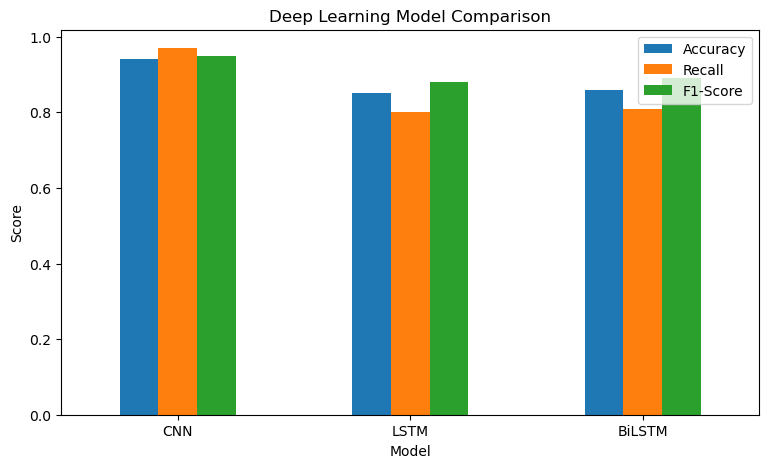

In [61]:
import matplotlib.pyplot as plt

df_dl.plot(
    x="Model",
    y=["Accuracy", "Recall", "F1-Score"],
    kind="bar",
    figsize=(9,5)
)

plt.title("Deep Learning Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


In [64]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df_feat_hyb = pd.read_csv("final_dataset_with_all_features_v3.1.csv")

X_feat_hyb = df_feat_hyb.drop(columns=['label'])
X_feat_hyb = X_feat_hyb.select_dtypes(include=['float64', 'int64'])
y_hyb = df_feat_hyb['label']

scaler = StandardScaler()
X_feat_hyb_scaled = scaler.fit_transform(X_feat_hyb)


In [65]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

df_nlp_hyb = pd.read_csv("phishing_urls_nlp_dataset.csv")

X_text_hyb = df_nlp_hyb['clean_url']

max_chars = 200
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(X_text_hyb)

seq = tokenizer.texts_to_sequences(X_text_hyb)
X_nlp_seq = pad_sequences(seq, maxlen=max_chars, padding='post')


In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalMaxPooling1D, Input

vocab_size = len(tokenizer.word_index) + 1

embedding_model = Sequential([
    Input(shape=(max_chars,)),
    Embedding(vocab_size, 50,),
    GlobalMaxPooling1D()
])

X_nlp_emb = embedding_model.predict(X_nlp_seq)


20350/20350 ━━━━━━━━━━━━━━━━━━━━ 14s 661us/step


In [68]:
import numpy as np

X_hybrid = np.concatenate([X_feat_hyb_scaled, X_nlp_emb], axis=1)


In [74]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

X_train_hyb, X_test_hyb, y_train_hyb, y_test_hyb = train_test_split(
    X_hybrid, y_hyb,
    test_size=0.2,
    random_state=42,
    stratify=y
)

hybrid_model = Sequential([
    Input(shape=(X_train_hyb.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

hybrid_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hybrid_model.fit(
    X_train_hyb, y_train_hyb,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/10
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8484 - loss: 0.3874 - val_accuracy: 0.8665 - val_loss: 0.3279
Epoch 2/10
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8626 - loss: 0.3405 - val_accuracy: 0.8748 - val_loss: 0.3109
Epoch 3/10
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8698 - loss: 0.3253 - val_accuracy: 0.8856 - val_loss: 0.3007
Epoch 4/10
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8791 - loss: 0.3113 - val_accuracy: 0.8957 - val_loss: 0.2807
Epoch 5/10
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8876 - loss: 0.2990 - val_accuracy: 0.9035 - val_loss: 0.2675
Epoch 6/10
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8931 - loss: 0.2883 - val_accuracy: 0.9062 - val_loss: 0.2618
Epoch 7/10
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8941 - loss: 0.2856 - val_accuracy: 0.9075 - val_loss: 0.2575
Epoch 8/10
3663/3663 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8953 - loss: 0.2817 - 

In [80]:
from sklearn.metrics import classification_report, confusion_matrix

hybrid_probs = hybrid_model.predict(X_test_hyb)
y_pred_hyb = np.argmax(hybrid_probs, axis=1)

cm_hybrid = confusion_matrix(y_test_hyb, y_pred_hyb)

print(confusion_matrix(y_test_hyb, y_pred_hyb))
print(classification_report(y_test_hyb, y_pred_hyb))

fn_hybrid = {}

for i in range(cm_hybrid.shape[0]):
    fn_hybrid[f"Class_{i}"] = cm_hybrid[i].sum() - cm_hybrid[i][i]

print("Hybrid False Negatives per class:", fn_hybrid)
print("Total Hybrid False Negatives:", sum(fn_hybrid.values()))

4070/4070 ━━━━━━━━━━━━━━━━━━━━ 2s 580us/step
[[84112   190  1298    21]
 [   82 19040   135    35]
 [ 8292  1103  9328    99]
 [  115   488   389  5512]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     85621
           1       0.91      0.99      0.95     19292
           2       0.84      0.50      0.62     18822
           3       0.97      0.85      0.91      6504

    accuracy                           0.91    130239
   macro avg       0.91      0.83      0.86    130239
weighted avg       0.90      0.91      0.90    130239

Hybrid False Negatives per class: {'Class_0': np.int64(1509), 'Class_1': np.int64(252), 'Class_2': np.int64(9494), 'Class_3': np.int64(992)}
Total Hybrid False Negatives: 12247


In [5]:
df_final = pd.read_csv("phishing_urls_nlp_dataset.csv")


In [6]:
from sklearn.model_selection import train_test_split

X_final = df_final['clean_url']   
y_final = df_final['label']

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    stratify=y,
    random_state=42
)


NameError: name 'y' is not defined

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_final = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=50000
)

X_train_tfidf_final = tfidf_final.fit_transform(X_train_final)
X_test_tfidf_final = tfidf_final.transform(X_test_final)


NameError: name 'X_train_final' is not defined

In [111]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.utils import shuffle


param_grid = {
    'C': [0.1, 1, 10, 100],  
    'loss': ['hinge', 'squared_hinge'] 
}

X_tune, y_tune = shuffle(X_train_tfidf_final, y_train_final, n_samples=20000, random_state=42)


grid = GridSearchCV(
    LinearSVC(max_iter=3000, class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='recall_macro',
    n_jobs=-1
)

grid.fit(X_tune, y_tune)
print("Best Parameters:", grid.best_params_)
print("Best Recall Score:", grid.best_score_)

Best Parameters: {'C': 1, 'loss': 'hinge'}
Best Recall Score: 0.844285870874118


In [113]:
final_svm = LinearSVC(
    C=1,
    loss='squared_hinge',
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

final_svm.fit(X_train_tfidf_final, y_train_final)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [114]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_final = final_svm.predict(X_test_tfidf_final)

cm_final = confusion_matrix(y_test_final, y_pred_final)
print(cm_final)
print(classification_report(y_test_final, y_pred_final))

def compute_fn(cm_final):
    return sum([cm_final[i].sum() - cm_final[i][i] for i in range(cm_final.shape[0])])

total_fn = compute_fn(cm_final)
print("Total False Negatives:", total_fn)


[[81254   366  3961    40]
 [   96 19122    72     2]
 [ 2538   155 16084    45]
 [   33     4   188  6279]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     85621
           1       0.97      0.99      0.98     19292
           2       0.79      0.85      0.82     18822
           3       0.99      0.97      0.98      6504

    accuracy                           0.94    130239
   macro avg       0.93      0.94      0.93    130239
weighted avg       0.94      0.94      0.94    130239

Total False Negatives: 7500


In [115]:
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y_test_final, y_pred_final))
print("Weighted F1:", f1_score(y_test_final, y_pred_final, average='weighted'))


Accuracy: 0.9424135627576993
Weighted F1: 0.9431668787459112


In [2]:
import joblib

joblib.dump(final_svm, "final_phishing_svm_model.pkl")
joblib.dump(tfidf_final, "final_tfidf_vectorizer.pkl")


NameError: name 'final_svm' is not defined

In [8]:
final_svm = joblib.load("final_phishing_svm_model.pkl")
tfidf_final = joblib.load("final_tfidf_vectorizer.pkl")


C:\Users\Kunal Saxena\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Kunal Saxena\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Kunal Saxena\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.2 when using version 1.5.1. This mig

In [118]:
def predict_url(url):
    url = url.lower()
    url_vec = tfidf_final.transform([url])
    prediction = final_svm.predict(url_vec)
    return prediction[0]

# Example
predict_url("www.youtube.com/")


np.int64(0)

In [101]:
#missed urls by the model
import numpy as np

y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred_svm)

false_negative_indices = np.where(
    (y_test_arr == 1) & (y_pred_arr == 0)
)[0]

df.iloc[false_negative_indices][['url', 'clean_url']].head(10)


,url,clean_url
3653,en.wikipedia.org/wiki/2007%E2%80%9308_Michigan...,en.wikipedia.org/wiki/2007%e2%80%9308_michigan...
13501,dorseypaintingny.com/,dorseypaintingny.com/
13699,http://saborlatinosp.it/it/fotogallery/7-marem...,saborlatinosp.it/it/fotogallery/7-maremma-que-...
14072,answers.yahoo.com/question/index?qid=200811021...,answers.yahoo.com/question/index?qid=200811021...
16347,0245acc00unt-info001.000webhostapp.com,0245acc00unt-info001.000webhostapp.com
19584,http://fishki.net/video/1526688-sud-naznachil-...,fishki.net/video/1526688-sud-naznachil-vasilev...
22007,http://alviksby.se/index.php?view=details&id=1...,alviksby.se/index.php?view=details&id=1:julmar...
22501,http://speyerseminar.de/cms/index.php?option=c...,speyerseminar.de/cms/index.php?option=com_docm...
27265,tvguide.com/News/Battlestar-Galacticas-Alessan...,tvguide.com/news/battlestar-galacticas-alessan...
31385,habsfeed.com/page/2/,habsfeed.com/page/2/


In [4]:
# Core Libraries
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
# Machine Learning
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, LSTM, Bidirectional, Conv1D, GlobalMaxPooling1D, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Model Saving
import joblib
